In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Loaded unemployment data from Kaggle (Region-wise, up to Nov 2020). Using this file since it has region + area info.

In [19]:
# Loading unemployment data from Kaggle (Region-wise, up to Nov 2020)
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [20]:
# Checked shape, nulls, fixed Date column to datetime
print(df.shape)
df.isnull().sum()

(267, 9)


Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

In [29]:

df.columns = df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [30]:
df.dtypes

Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Region.1                                    object
longitude                                  float64
latitude                                   float64
dtype: object

In [31]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.dtypes

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Region.1                                           object
longitude                                         float64
latitude                                          float64
dtype: object

In [32]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


267 rows, no missing values. Date column was text originally so converted it to datetime, also stripped extra spaces from column names.

In [33]:
# region-wise average unemployment rate
avg_region = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
avg_region

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64

In [34]:
# extracting month from date for month-wise trend
df['Month'] = df['Date'].dt.month

monthly_data = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
monthly_data

Month
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name: Estimated Unemployment Rate (%), dtype: float64

In [35]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal'], dtype=object)

Some states clearly higher than others on avg. Month-wise there's a jump around April, matches when lockdown started.

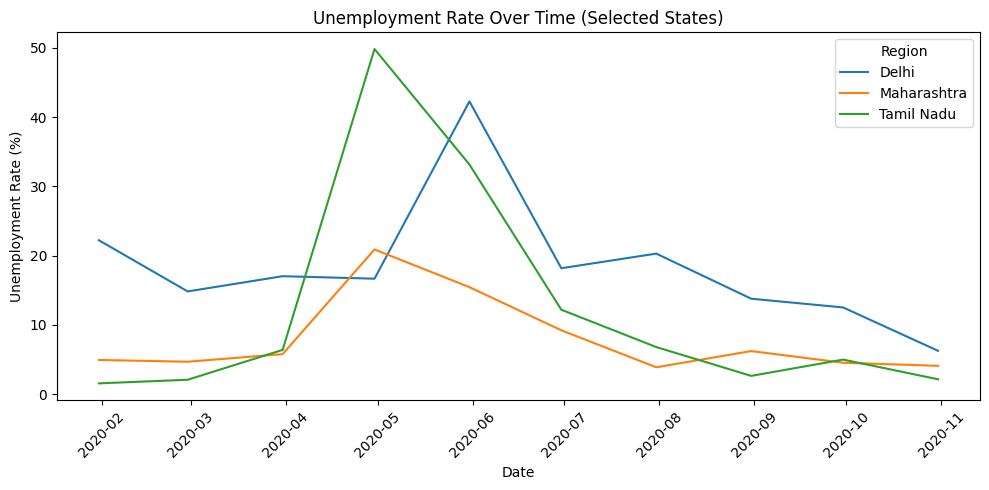

In [41]:
# Delhi, Maharashtra, Tamil Nadu over time
states_to_check = ['Delhi', 'Maharashtra', 'Tamil Nadu']
state_data = df[df['Region'].isin(states_to_check)]

plt.figure(figsize=(10,5))
sns.lineplot(data=state_data, x='Date', y='Estimated Unemployment Rate (%)', hue='Region')
plt.title('Unemployment Rate Over Time (Selected States)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('unemployment_Rate_Over_Time.png')
plt.show()

Tamil Nadu spikes hardest, close to 50% around May 2020. Delhi peaks a bit later around June, above 40%. Maharashtra barely moves compared to these two, kind of surprising since it had a lot of covid cases. All three settle down by Sep-Oct.

C:\Users\yogender\AppData\Local\Temp\ipykernel_16940\2701395043.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='viridis')


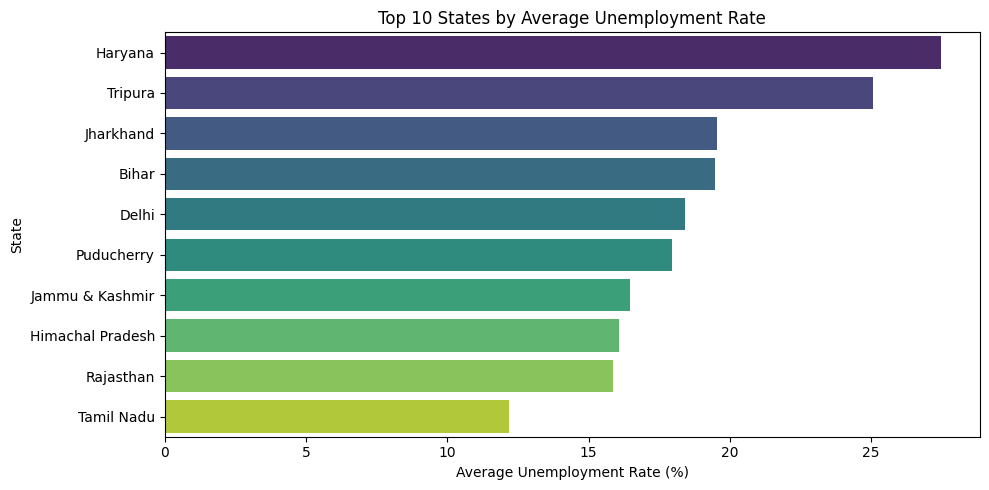

In [43]:
# TN peaks highest (~50%) in May, Delhi peaks in June, Maharashtra barely moves
top_states = avg_region.head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_states.values, y=top_states.index, palette='viridis')
plt.title('Top 10 States by Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('Top_10_States_Average_Unemployment_Rate.png')
plt.show()

Haryana and Tripura have highest avg unemployment, both above 25%. Tamil Nadu doesn't even show up in top 10 despite the big spike earlier — that was more of a short term thing, not consistently high through the year.

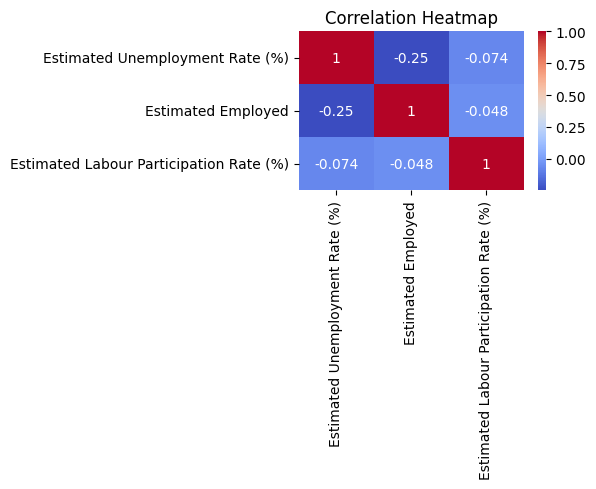

In [44]:
# Haryana & Tripura on top. TN not in top 10 despite its spike - was short-term, not sustained

# Checking correlation between unemployment, employed count, labour participation
cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr_data = df[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_data, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

Unemployment vs employed has weak negative correlation (-0.25), makes some sense. Unemployment vs labour participation rate is almost 0 (-0.074), wasn't expecting that, thought these would be more related.

In [39]:
# Split data at March 25 2020 (lockdown start) to compare pre/post

covid_start = '2020-03-25'

pre_covid = df[df['Date'] < covid_start]
post_covid = df[df['Date'] >= covid_start]

pre_covid_avg = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_covid_avg = post_covid['Estimated Unemployment Rate (%)'].mean()

print("Pre-COVID average:", pre_covid_avg)
print("Post-COVID average:", post_covid_avg)

Pre-COVID average: 9.231346153846154
Post-COVID average: 12.963860465116278


Pre-COVID avg was 9.23%, post-COVID jumped to 12.96%, about 40% higher. Matches the spike from the line chart. Stayed high for a while after lockdown, not just one month.

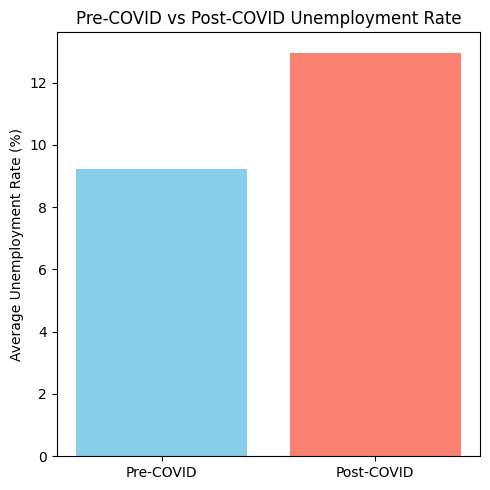

In [40]:
# 9.23% pre vs 12.96% post, ~40% jump

# Unemployment rose ~40% post-lockdown. TN/Delhi spiked hardest short-term, Haryana/Tripura stayed high overall.
# Labour participation didn't correlate much with unemployment rate.
plt.figure(figsize=(5,5))
plt.bar(['Pre-COVID', 'Post-COVID'], [pre_covid_avg, post_covid_avg], color=['skyblue', 'salmon'])
plt.title('Pre-COVID vs Post-COVID Unemployment Rate')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

Unemployment rose sharply after lockdown, post-COVID avg about 40% higher than pre-COVID. Tamil Nadu and Delhi had the biggest short-term spikes, but Haryana and Tripura stayed high on average overall. Labour participation rate didn't correlate much with unemployment, which was one of the more surprising findings. Overall covid clearly disrupted jobs across states but not evenly — some recovered faster than others.